## AE33 TCP/IP Communication Guide

This notebook demonstrates how to communicate with the **AE33 Aethalometer** using its TCP/IP interface for real-time data acquisition and control.

**License:** Aerosol Magee Scientific Software License. See LICENSE file for full terms.

In [11]:
from io import StringIO
import re

import pandas as pd

from aerosol_magee_pytools.data_access.tcp_ip import request_tcp

In [12]:
# IP of the instrument - change it to the actual IP address of your AE33 instrument
instrument_ip = '10.10.10.224'

timeout = 2.0  # seconds

In [13]:
# default column names
COLUMNS_AE33_DATA = ['SerialNumber', 'ID', 'StartTime', 'EndTime', 'SetupID', 'SetupTimestamp',
                     'Ref1', 'Sens11', 'Sens12', 'Ref2', 'Sens21', 'Sens22',
                     'Ref3', 'Sens31', 'Sens32', 'Ref4', 'Sens41', 'Sens42',
                     'Ref5', 'Sens51', 'Sens52', 'Ref6', 'Sens61', 'Sens62',
                     'Ref7', 'Sens71', 'Sens72',
                     'BC11', 'BC12', 'BC1', 'BC21', 'BC22', 'BC2',
                     'BC31', 'BC32', 'BC3', 'BC41', 'BC42', 'BC4',
                     'BC51', 'BC52', 'BC5', 'BC61', 'BC62', 'BC6',
                     'BC71', 'BC72', 'BC7',
                     'K1', 'K2', 'K3', 'K4', 'K5', 'K6', 'K7', 'BB',
                     'Pressure', 'Temp', 'Flow1', 'Flow2', 'FlowC',
                     'T_controller', 'T_supply', 'T_LED', 'ControllerStatus',
                     'LEDStatus', 'DetectorStatus', 'ValveStatus', 'Status',
                     'TapeAdvanceCount', 'TapeAdvanceLeft', 'CPU', 'DiskSpace', 'NumConnections']
COLUMNS_AE33_EXTERNAL_DEVICE_DATA = ['SerialNumber', 'ID', 'DataID', 'DeviceID', 'DeviceData']
COLUMNS_AE33_SETUP = ['serial', 'ID', 'SerialNumber', 'Timestamp', 'FirmwareVer', 'SoftwareVer',
                      'DataCenterIP', 'AutoConnect', 'InletFilter',
                      'Timebase', 'SG1', 'SG2', 'SG3', 'SG4', 'SG5', 'SG6', 'SG7',
                      'C', 'Area', 'Zeta', 'Aff', 'Abb', 'Pressure', 'Temp',
                      'ATNf1', 'ATNf2', 'Kmax', 'Kmin', 'Flow', 'FlowRepStd',
                      'PumpPresetValue', 'FlowFormulaA0', 'FlowFormulaA1',
                      'FlowFormulaB0', 'FlowFormulaB1', 'FlowFormulaC0',
                      'FlowFormulaC1', 'FlowFormulaD', 'FlowFormulaE',
                      'FlowFormulaF', 'TAtype', 'TAatnMax', 'TAinterval',
                      'TAtime', 'TapeRightFormulaK', 'TapeRightFormulaN',
                      'TapeLeftFormulaK', 'TapeLeftFormulaN', 'WarmUpInterval',
                      'AutoTestEnabled', 'AutoTestType', 'AutoTestDay', 'AutoTestTime',
                      'MeasureTimeStamp', 'HomeInfo', 'Display', 'About', 'DST', 'TimeZone',
                      'TapeAdvanceAdjust', 'ExternalID', 'BHparamID', 'TimeSync', 'DHCP',
                      'InstrumentIP', 'SubnetMask', 'Gateway', 'Baud', 'NTPserver']

In [14]:
### command HELLO
command_ae33 = 'HELLO\r\n'

received_text = request_tcp(ip=instrument_ip,
                            command=command_ae33,
                            timeout=timeout)
print(received_text)

AE33>Aethalometer information
Server type: AE33
Instrument serialnumber: AE33-S06-00565
Time: 23/Jun/2026 10:44:42
Database version: 1.7.3
Connected Clients: 3
ID: 1441957  IP: 192.168.45.37:51226  Time: 23 Jun 2026 10:44:42  Streaming: False
ID: 1384580  IP: 10.10.10.253:49760  Time: 16 Jun 2026 05:12:28  Streaming: True
ID: 1384579  IP: 10.10.10.253:49751  Time: 16 Jun 2026 05:12:28  Streaming: True

AE33>


In [15]:
### command MAXID Data
command_ae33 = 'MAXID Data\r\n'

received_text = request_tcp(ip=instrument_ip,
                            command=command_ae33,
                            timeout=timeout)
print(received_text)

# # parse data
max_data_id = int(re.search(r'AE33>(\d+)', received_text).group(1))
print()
print(max_data_id)


AE33>3176981
AE33>

3176981


In [20]:
### command FETCH Data - collect last 120 rows from table Data
command_ae33 = f'FETCH Data {max_data_id-120} {max_data_id}\r\n'

received_text = request_tcp(ip=instrument_ip,
                            command=command_ae33,
                            timeout=timeout)
print(received_text)

# in the end, you can parse data, for example convert it into pandas dataframe
df_ae33_data = pd.read_csv(StringIO(received_text.replace('AE33>', '').strip()),
                           sep='|',
                           names=COLUMNS_AE33_DATA)
print()
print(df_ae33_data)

AE33>AE33>AE33-S06-00565|3176861|6/23/2026 8:43:00 AM|6/23/2026 8:44:00 AM|26|7/29/2025 7:24:13 AM|905678|308377|500867|876518|365732|545076|891934|409832|557896|892398|431155|564430|899299|534980|692797|780375|657094|810244|859789|681758|815356|0|-8|0|11|-49|9|2|55|2|-6|-34|-6|18|-61|17|19|-2|20|-4|16|-4|-7.895158E-05|-0.002214113|-0.001941299|-0.0007784227|-0.0008634671|0.001269253|0.002449305|0|101325.0|21.1|3222|1185|4407|34.0|40.0|35.0|0|10|10|0|4|6066|285|5|5234|2
AE33>AE33-S06-00565|3176862|6/23/2026 8:44:00 AM|6/23/2026 8:45:00 AM|26|7/29/2025 7:24:13 AM|905717|308378|500879|876564|365741|545098|891977|409843|557915|892458|431172|564453|899386|535023|692860|780430|657132|810303|859874|681824|815433|38|50|38|34|40|30|29|52|26|43|110|41|28|27|27|29|-15|30|5|30|5|-7.927512E-05|-0.002214713|-0.001940787|-0.000774818|-0.000864874|0.001263527|0.002450603|100|101325.0|21.1|3222|1183|4405|34.0|40.0|36.0|0|10|10|0|4|6066|285|11|5234|2
AE33>AE33-S06-00565|3176863|6/23/2026 8:45:00 AM|6/2

In [17]:
### collect data from Setup table
command_ae33 = f'FETCH SETUP\r\n'

received_text = request_tcp(ip=instrument_ip,
                            command=command_ae33,
                            timeout=timeout)
print(received_text)

# in the end, you can parse data, for example convert it into pandas dataframe
df_ae33_setup = pd.read_csv(StringIO(received_text.replace('AE33>', '').strip()),
                            sep='|',
                            names=COLUMNS_AE33_SETUP)
# drop duplicated serial column from setup data
df_ae33_setup = df_ae33_setup.drop(columns=['serial'], errors='ignore')
print()
print(df_ae33_setup)

AE33>AE33-S06-00565|1|AE33-S06-00565|10/30/2020 4:47:54 PM|533|1.4.9.1|10.10.10.253:8007|1|0|60|18.47|14.54|13.14|11.58|10.35|7.77|7.19|1.39|0.785|0.02|1|2|101325|25.00|10|30|0.015|-0.005|2000|1|585|-1952.80444335937|-2505.5458984375|11.6349792480469|12.9688386917114|0.000753700849600136|-0.000350014335708693|166.16487121582|0.0840134471654892|-4.06122467211389E-07|1|120|12|3/13/2017 10:57:40 AM|1.04204201698303|1.88889074325562|1.12658226490021|-45.7848091125488|1|1|0|2|1/1/2014 12:00:00 AM|1|0|1|0|0|Coordinated Universal Time|10|1|1|1|1|192.168.0.2|255.255.255.0|192.168.0.1|115200|pool.ntp.org
AE33>AE33>AE33-S06-00565|13|AE33-S06-00565|9/14/2021 7:23:04 AM|540|1.5.0.1|10.10.10.253:8007|1|0|60|18.47|14.54|13.14|11.58|10.35|7.77|7.19|1.39|0.785|0.02|1|2|101325|25.00|10|30|0.015|-0.005|2000|1|585|-1952.80444335937|-2505.5458984375|11.6349792480469|12.9688386917114|0.000753700849600136|-0.000350014335708693|166.16487121582|0.0840134471654892|-4.06122467211389E-07|1|120|12|3/13/2017 10:57

In [18]:
### collect data from ExtDeviceData table - get MAXID and then fetch last 5 rows

command_ae33 = 'MAXID ExtDeviceData\r\n'
received_text = request_tcp(ip=instrument_ip,
                            command=command_ae33,
                            timeout=timeout)
print(received_text)
max_ext_device_data_id = int(re.search(r'AE33>(\d+)', received_text).group(1))

command_ae33 = f'FETCH ExtDeviceData {max_ext_device_data_id-5} {max_ext_device_data_id}\r\n'
received_text = request_tcp(ip=instrument_ip,
                            command=command_ae33,
                            timeout=timeout)
print(received_text)

# in the end, you can parse data, for example convert it into pandas dataframe
df_ae33_device_data = pd.read_csv(StringIO(received_text.replace('AE33>', '').strip()),
                           sep='|',
                           names=COLUMNS_AE33_EXTERNAL_DEVICE_DATA)
print()
print(df_ae33_device_data)

AE33>4460421
AE33>
AE33>AE33-S06-00565|4460416|3176976|15|99
AE33>AE33>AE33-S06-00565|4460417|3176977|15|99
AE33>AE33-S06-00565|4460418|3176978|15|99
AE33>AE33-S06-00565|4460419|3176979|15|99
AE33>AE33-S06-00565|4460420|3176980|15|99
AE33>AE33-S06-00565|4460421|3176981|15|99
AE33>

     SerialNumber       ID   DataID  DeviceID  DeviceData
0  AE33-S06-00565  4460416  3176976        15          99
1  AE33-S06-00565  4460417  3176977        15          99
2  AE33-S06-00565  4460418  3176978        15          99
3  AE33-S06-00565  4460419  3176979        15          99
4  AE33-S06-00565  4460420  3176980        15          99
5  AE33-S06-00565  4460421  3176981        15          99


<Axes: title={'center': 'AE33'}, xlabel='EndTime', ylabel='BC ($ng/m^3$)'>

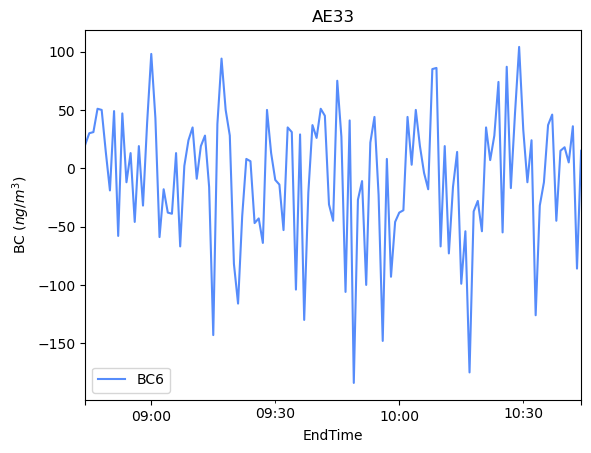

In [21]:
# plot example
df_ae33_data['EndTime'] = pd.to_datetime(df_ae33_data['EndTime'], errors='coerce')
df_ae33_data.plot(x='EndTime', y='BC6', title=f'AE33', ylabel='BC ($ng/m^3$)')